# Report 2: Exploration of energy usage and devices

This report aims to answer the following questions:

- Which months have higher energy and gas usage?
- What patterns emerge from gas and electricity usage over time? (Cluster analysis)


In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from home_messages_db import *
import datetime
db = HomeMessagesDB("sqlite:///myhome.db")
db.create_db()

First lets insert the files into the database

In [7]:
db.erase_table_content("P1e")
files = check_filepaths("P1e-*.csv.gz","P1e") + check_filepaths("P1e-*.csv","P1e")
for file in files:
    db.insert_table_P1e(file)

Are you sure you want to erase all contents of this table from the database? Y/N
Data in table P1e deleted successfully


In [8]:
db.erase_table_content("smartthings")
files = check_filepaths("smartthings*.tsv.gz","smartthings")

for file in files:
    db.insert_table_smartthings(file)

Are you sure you want to erase all contents of this table from the database? Y/N
Data in table smartthings deleted successfully


In [9]:
db.erase_table_content("P1g")
files = check_filepaths("P1g-*.csv.gz","P1g") + check_filepaths("P1g-*.csv","P1g")
for file in files:
    db.insert_table_P1g(file)

Are you sure you want to erase all contents of this table from the database? Y/N
Data in table P1g deleted successfully


And now fetch them and insert them into a pandas dataframe

In [10]:
smart_things = db.return_whole_table("smartthings")
p1e = db.return_whole_table("P1e")
p1g = db.return_whole_table("P1g")

Prepare data:

In [ ]:
p1e["date"] = pd.to_datetime(p1e.loc[:,"epoch"]*10**9)
p1e["time"] = pd.to_datetime(p1e.loc[:,"epoch"]*10**9).dt.strftime("%H:%M")
p1e["year"] = p1e["date"].dt.year
p1e["month"] = p1e["date"].dt.month

p1e["Usage"] = (p1e.loc[:,"Electricity_imported_T1"].diff() +p1e.loc[:,"Electricity_imported_T2"].diff() ).fillna(0)

p1g["date"] = pd.to_datetime(p1e.loc[:,"epoch"]*10**9)
p1g["year"] = p1g["date"].dt.year
p1g["month"] = p1g["date"].dt.month
p1g["day_as_date"]=p1g["date"].dt.date
p1g["Usage"] = (p1g["Total_gas_used"].diff()).fillna(0)

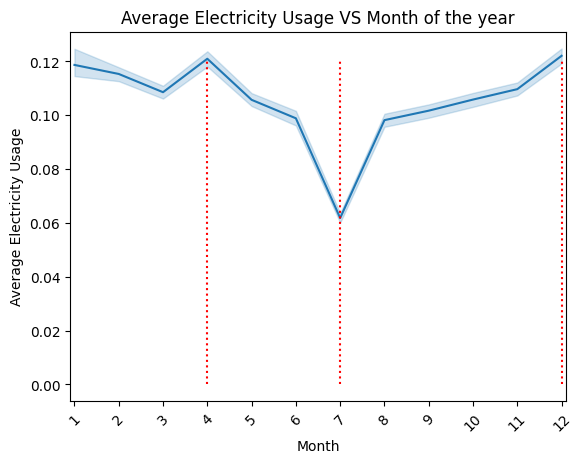

In [89]:
ax = sns.lineplot(p1e, x = "month", y = "Usage", estimator= "mean")
plt.xticks(np.arange(0,13, step = 1), rotation = 45, labels = range(0,13,1))
plt.xlim(0.9, 12.1)
plt.vlines(x = [4,12,7], ymin = 0, ymax= 0.12, linestyles= "dotted", color = "red")
ax.set(xlabel = "Month", ylabel = "Average Electricity Usage", title = "Average Electricity Usage VS Month of the year")
plt.show()

We see that energy consumption is higher in the months of April and December, and at it's lowest in the month of July. 

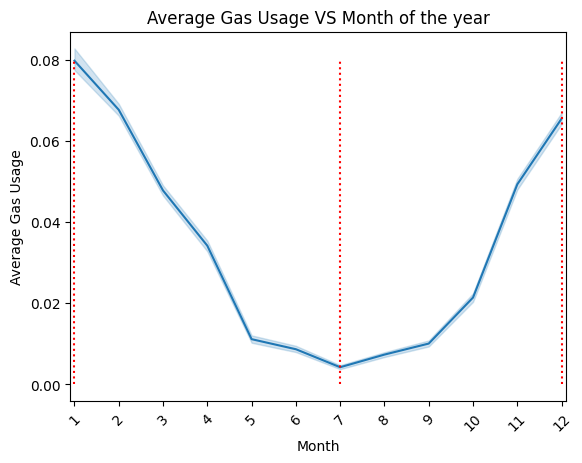

In [97]:
ax = sns.lineplot(p1g, x = "month", y = "Usage", estimator= "mean")
plt.xticks(np.arange(0,13, step = 1), rotation = 45, labels = range(0,13,1))
plt.xlim(0.9, 12.1)
plt.vlines(x = [1,12,7], ymin = 0, ymax= 0.08, linestyles= "dotted", color = "red")
ax.set(xlabel = "Month", ylabel = "Average Gas Usage", title = "Average Gas Usage VS Month of the year")
plt.show()

As expected we can see the consumption of gas is on average higher on the colder months, and lower in the summer months, since then no heating is used.